In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import random

In [76]:
# Read train, val, test
train_df = pd.read_csv("dataset/LSTM/train_lstm.csv")
val_df = pd.read_csv("dataset/LSTM/val_lstm.csv")
test_df = pd.read_csv("dataset/LSTM/test_lstm.csv")

In [77]:
train_df.head()

,period,idr_usd,inflation_rate,interest_rate,realized_return,cond_vol
0,2015-01-05,12652.0,6.96,7.75,0.009211,0.005032
1,2015-01-06,12721.0,6.96,7.75,0.005439,0.005578
2,2015-01-07,12796.0,6.96,7.75,0.005878,0.005540
3,2015-01-08,12795.0,6.96,7.75,0.000078,0.005552
4,2015-01-09,12703.0,6.96,7.75,0.007216,0.005242


In [78]:
val_df.head()

,period,idr_usd,inflation_rate,interest_rate,realized_return,cond_vol
0,2022-01-03,14349.39,2.18,3.5,0.000630,0.002599
1,2022-01-04,14341.35,2.18,3.5,0.000560,0.002518
2,2022-01-05,14381.55,2.18,3.5,0.002799,0.002442
3,2022-01-06,14436.83,2.18,3.5,0.003836,0.002527
4,2022-01-07,14467.98,2.18,3.5,0.002155,0.002729


In [79]:
test_df.tail()

,period,idr_usd,inflation_rate,interest_rate,realized_return,cond_vol
472,2024-12-23,16351.35,1.57,6.0,0.000430,0.004207
473,2024-12-24,16239.80,1.57,6.0,0.006845,0.004207
474,2024-12-27,16289.04,1.57,6.0,0.003027,0.004207
475,2024-12-30,16332.25,1.57,6.0,0.002649,0.004207
476,2024-12-31,16242.81,1.57,6.0,0.005491,0.004207


## GARCH-LSTM (Features: Raw Price and GARCH-based Volatility)

## Scaling

In [11]:
#Scaling
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

features = ['idr_usd', 'cond_vol']

# Buat scaler untuk input fitur
scaler_X = MinMaxScaler(feature_range=(0,1))

# Fit scaler hanya pada TRAINING data (hindari data leakage)
scaler_X.fit(train_df[features])

# Transform train, val, test pakai scaler yg sama
train_scaled = scaler_X.transform(train_df[features])
val_scaled   = scaler_X.transform(val_df[features])
test_scaled  = scaler_X.transform(test_df[features])

# Jika target yang diprediksi hanya harga (idr_myr)
scaler_y = MinMaxScaler(feature_range=(0,1))
scaler_y.fit(train_df[['idr_usd']])

y_train_scaled = scaler_y.transform(train_df[['idr_usd']])
y_val_scaled   = scaler_y.transform(val_df[['idr_usd']])
y_test_scaled  = scaler_y.transform(test_df[['idr_usd']])

## Windowing

In [21]:
def create_windowed_data_multivariate(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :])
        y.append(data[i+seq_length, 0])
    return np.array(X), np.array(y)

WINDOW_SIZE = 30

X_train, y_train = create_windowed_data_multivariate(train_scaled, WINDOW_SIZE)
X_val, y_val     = create_windowed_data_multivariate(val_scaled, WINDOW_SIZE)
X_test, y_test   = create_windowed_data_multivariate(test_scaled, WINDOW_SIZE)

print("X_train shape:", X_train.shape)  # (samples, 30, 2)
print("y_train shape:", y_train.shape)  # (samples,)

X_train shape: (1696, 30, 2)
y_train shape: (1696,)


## Data Reshaping

Since the GARCH-LSTM model uses **two features**, the input arrays must be reshaped to fit the LSTM's expected 3D input shape:
- **X_train, X_val, X_test** are reshaped to `(num_samples, window_size, 2)` where `2` corresponds to the two input features.  
- **y_train, y_val, y_test** are reshaped to `(num_samples, 1)` because the model predicts a **single output** (next day log-return or price).

This ensures that the LSTM correctly interprets **each sequence of 30 timesteps** with both features for learning temporal dependencies.

In [17]:
# Input Features (X)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 2))
X_val   = X_val.reshape((X_val.shape[0], X_val.shape[1], 2))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 2))

print("X_train reshaped:", X_train.shape)
print("X_val reshaped:", X_val.shape)
print("X_test reshaped:", X_test.shape)

# Target (y) -> 1 output
y_train = y_train.reshape(-1, 1)
y_val   = y_val.reshape(-1, 1)
y_test  = y_test.reshape(-1, 1)

print("y_train reshaped:", y_train.shape)
print("y_val reshaped:", y_val.shape)
print("y_test reshaped:", y_test.shape)

X_train reshaped: (1696, 30, 2)
X_val reshaped: (216, 30, 2)
X_test reshaped: (447, 30, 2)
y_train reshaped: (1696, 1)
y_val reshaped: (216, 1)
y_test reshaped: (447, 1)


## Baseline Model Implementation

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

base_model = Sequential([
    LSTM(50, input_shape=(WINDOW_SIZE, 2)),  # units default 50, features = 2
    Dense(1)  # output : prediksi 1 nilai
])

# Compile model
base_model.compile(optimizer=Adam(), loss='mse')

# Fit model using default parameter
history_base = base_model.fit(
    X_train, y_train, # data training
    epochs=50, # dataset is iterated for 50 times
    batch_size=32, # update weights tiap 32 data
    validation_data=(X_val, y_val), # monitor performa model saat training -> using data validation
    verbose=1
)

# Evaluasi base model
base_eval = base_model.evaluate(X_test, y_test, verbose=0)
print("Base model test MSE:", base_eval)

C:\Users\Aileen\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0188 - val_loss: 0.0035
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0018 - val_loss: 6.1152e-04
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0014 - val_loss: 4.5913e-04
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0012 - val_loss: 5.6006e-04
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0011 - val_loss: 7.8521e-04
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 9.7854e-04 - val_loss: 8.6021e-04
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 8.9594e-04 - val_loss: 9.8117e-04
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 8.2968e-04 - val_loss: 0.0011
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 7.7790e-04 - val_loss: 0.0012
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 7.3781e-04 - val_loss: 0.0013
Epoch 11/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 7.0498e-04 - val_loss: 0.0013
Epoch 12/50
53/

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_test_true = scaler_y.inverse_transform(y_test.reshape(-1,1))
y_test_pred_original = scaler_y.inverse_transform(base_model.predict(X_test))

# RMSE, MAE, MAPE, R2 untuk test set
rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred_original))
mae = mean_absolute_error(y_test_true, y_test_pred_original)
r2 = r2_score(y_test_true, y_test_pred_original)

print(f"Test RMSE: {rmse:.6f}")
print(f"Test MAE: {mae:.6f}")
print(f"Test R2: {r2:.6f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
Test RMSE: 154.054258
Test MAE: 138.955089
Test R2: 0.874850


## Hyperparameter Tuning (HPT)

In [19]:
from tensorflow.keras.models import Sequential
from kerastuner.tuners import RandomSearch
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

def build_model(hp):
    model = Sequential()
    
    # Hyperparameter: jumlah unit LSTM
    units = hp.Int('units', min_value=32, max_value=128, step=16)
    model.add(LSTM(units, return_sequences=False, input_shape=(WINDOW_SIZE, 2)))

    # Hyperparameter: Dropout
    dropout_rate = hp.Choice('dropout_rate', values=[0.0, 0.2, 0.4])
    model.add(Dropout(dropout_rate))
    
    # Hyperparameter: learning rate
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    
    return model

#TUNER SETUP
tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=15,
    executions_per_trial=2,
    directory='my_dir',
    project_name='garch-lstm_tuning'
)

# CALLBACK FOR EARLY STOPPING
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# EXECUTE TUNING
tuner.search(
    X_train, y_train,
    epochs=600,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# GET BEST MODEL
best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters(1)[0]

print("Best Hyperparameters:")
print(best_hyperparameters.values)

# SUMMARY
best_model.summary()

Trial 15 Complete [00h 02m 27s]
val_loss: 0.00045625267375726253

Best val_loss So Far: 0.00013185085117584094
Total elapsed time: 00h 24m 35s
Best Hyperparameters:
{'units': 64, 'dropout_rate': 0.4, 'learning_rate': 0.01}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          17,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,217 (67.25 KB)

 Trainable params: 17,217 (67.25 KB)

 Non-trainable params: 0 (0.00 B)

## Final Training Model

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#Combine train & val sets
final_train_data = np.concatenate((train_scaled, val_scaled))
X_train_new, y_train_new = create_windowed_data_multivariate(final_train_data, WINDOW_SIZE)

# Test data tetap dipakai untuk evaluasi
X_test, y_test = create_windowed_data_multivariate(test_scaled, WINDOW_SIZE)

#Best parameters
units = 64
learning_rate = 0.01
dropout_rate = 0.4

model = Sequential([
    LSTM(units, return_sequences=False, input_shape=(WINDOW_SIZE, 2)),
    Dropout(dropout_rate),
    Dense(1)
])
model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')

# CALLBACK FOR EARLY STOPPING
early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_new, y_train_new,
    epochs=600,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Prediksi
y_train_pred = model.predict(X_train_new)
y_test_pred = model.predict(X_test)

# Kembali ke skala asli
y_train_true = scaler_y.inverse_transform(y_train_new.reshape(-1,1))
y_train_pred_original = scaler_y.inverse_transform(y_train_pred)

y_test_true = scaler_y.inverse_transform(y_test.reshape(-1,1))
y_test_pred_original = scaler_y.inverse_transform(y_test_pred)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred_original))
mae = mean_absolute_error(y_test_true, y_test_pred_original)
r2 = r2_score(y_test_true, y_test_pred_original)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test R2: {r2:.4f}")

Epoch 1/600


C:\Users\Aileen\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0105
Epoch 2/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0033
Epoch 3/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0025
Epoch 4/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0018
Epoch 5/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0019
Epoch 6/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0016
Epoch 7/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0013
Epoch 8/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0013
Epoch 9/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0013
Epoch 10/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0010
Epoch 11/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 9.9377e-04
Epoch 12/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 9.9094e-04
Epoch 13/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 8.3528e-04
Epoch 14/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 8.3483e-04
Epoch 15/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step 

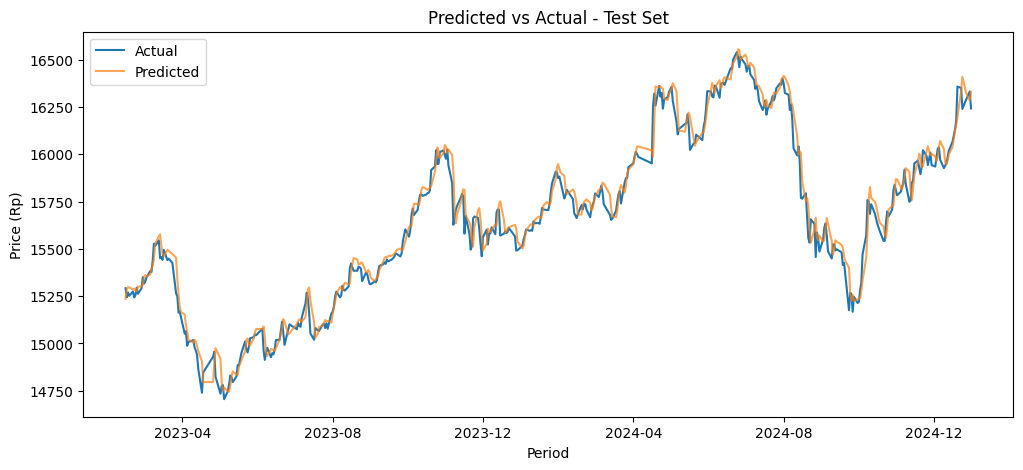

In [31]:
import matplotlib.dates as mdates

test_dates = pd.to_datetime(test_df['period'].iloc[WINDOW_SIZE:])

plt.figure(figsize=(12,5))
plt.plot(test_dates, y_test_true, label='Actual')
plt.plot(test_dates, y_test_pred_original, label='Predicted', alpha=0.7)

# Format x-axis
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # format YYYY-MM

plt.title("Predicted vs Actual - Test Set")
plt.xlabel("Period")
plt.ylabel("Price (Rp)")
plt.legend()

## Out-of-Sample Performance: Baseline vs Tuned Models

The GARCH-LSTM model is evaluated on the **unseen test set (2023–2024)**. Two scenarios are compared:

1. **Baseline Model Performance**  
   - Test RMSE: 154.05  
   - Test MAE: 138.96  
   - Test R²: 0.8749  

2. **Tuned Model Performance**  
   - Test RMSE: 67.47  
   - Test MAE: 50.11  
   - Test R²: 0.9760  

#### Key Takeaways

- **Significant improvement** after hyperparameter tuning: RMSE and MAE decreased drastically, R² increased.  
- Hyperparameter tuning allows the model to **better capture non-linear relationships** between price, volatility, and past trends.  
- Using **train + validation for final training** maximizes learning from available historical data while keeping test data unseen.  
- Overall, this demonstrates that **HPT is essential for achieving high predictive accuracy in GARCH-LSTM models**, especially when volatility features are included.

In [30]:
# Simpan the best GARCH-LSTM model (tuned)
model.save("model/best_model_garch-lstm_2features.keras")
print("💾 Model saved as best_model_garch-lstm_2features.keras")

💾 Model saved as best_model_garch-lstm_2features.keras


## Data Preparation - Trading Strategy Simulation

Based on the out-of-sample evaluation, the **GARCH-LSTM model with two input features (price and GARCH volatility)** is selected for the trading simulation.

The tuned model achieves the best predictive performance while maintaining a relatively simple feature structure. The inclusion of GARCH volatility allows the model to capture volatility clustering in the USD/IDR market, which is a key characteristic of financial time series.

In contrast, adding macroeconomic variables did not improve prediction accuracy and slightly reduced model performance. Therefore, the **price + volatility configuration** is used for the final trading strategy simulation.

Before running the backtesting simulation, the dataset is prepared by **merging key components** into a single table:

1. **Actual USD/IDR price** – the true market price  
2. **Predicted USD/IDR price** – generated by the GARCH-LSTM (price + volatility) model
3. **Estimated GARCH volatility** – the model’s conditional volatility
4. **Realized volatility** – the observed absolute returns

This consolidated dataset allows for **systematic backtesting** for trading strategy simulation.

In [84]:
# Create a dataframe called backtes

backtest_df = pd.DataFrame({
    "period": test_dates,
    "true_usd": y_test_true.flatten(),
    "pred_usd": y_test_pred_original.flatten(),
})
backtest_df.head()

,period,true_usd,pred_usd
30,2023-02-14,15292.08,15236.577148
31,2023-02-15,15243.84,15286.436523
32,2023-02-16,15269.97,15297.226562
33,2023-02-17,15251.88,15297.049805
34,2023-02-20,15275.00,15285.442383


In [87]:
# Pindahin juga realized_return dan cond_vol karena nanti juga akan dipake dibacktest
backtest_df.loc[backtest_df.index, 'realized_return'] = test_df['realized_return']
backtest_df.loc[backtest_df.index, 'cond_vol'] = test_df['cond_vol']

backtest_df

,period,true_usd,pred_usd,realized_return,cond_vol
30,2023-02-14,15292.08,15236.577148,0.005007,0.003585
31,2023-02-15,15243.84,15286.436523,0.003160,0.003598
32,2023-02-16,15269.97,15297.226562,0.001713,0.003611
33,2023-02-17,15251.88,15297.049805,0.001185,0.003624
34,2023-02-20,15275.00,15285.442383,0.001515,0.003637
...,...,...,...,...,...
472,2024-12-23,16351.35,16335.101562,0.000430,0.004207
473,2024-12-24,16239.80,16409.945312,0.006845,0.004207
474,2024-12-27,16289.04,16325.783203,0.003027,0.004207
475,2024-12-30,16332.25,16284.535156,0.002649,0.004207


In [88]:
backtest_df.to_csv("dataset/backtest_df.csv", index=False)